In [1]:
import torch

import sys
sys.path.append("../")
from utils import Learner

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
torch.cuda.empty_cache() 
# pip install importlib-metadata warp-lang

dry_run = False
# dry_run=True
save = not dry_run
epochs = 5 if dry_run else 500
print_every = 1 if dry_run else 10

## NS_Heat

In [ ]:
from utils import MPData
data_name = 'NS_heat'
model_name= 'MPodONet'
out_channels= 5 if data_name == 'MHD' else 3
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import MPodONet
from neuralop.utils import count_model_params
p = 1024
model = MPodONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 10,951,872 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 10,951,872


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 4.23/0.16 | loss: 2.74e-01 | test: 6.49e-02 | norm: 0.09


epoch:10 | time: 4.25/0.16 | loss: 1.01e-02 | test: 1.10e-02 | norm: 0.04


epoch:20 | time: 4.25/0.16 | loss: 5.66e-03 | test: 5.34e-03 | norm: 0.03


epoch:30 | time: 4.25/0.16 | loss: 3.60e-03 | test: 3.84e-03 | norm: 0.02


epoch:40 | time: 4.23/0.16 | loss: 2.54e-03 | test: 2.40e-03 | norm: 0.02


...

epoch:470 | time: 4.23/0.16 | loss: 2.19e-04 | test: 2.83e-04 | norm: 0.00


epoch:480 | time: 4.24/0.16 | loss: 2.18e-04 | test: 2.93e-04 | norm: 0.00


epoch:490 | time: 4.24/0.16 | loss: 2.14e-04 | test: 2.79e-04 | norm: 0.00


epoch:499 | time: 4.25/0.16 | loss: 2.12e-04 | test: 2.76e-04 | norm: 0.00


Finish epoch:499 | train loss: 2.1179e-04 | test loss: 2.7580e-04
total train time : 2119.962
Channel Loss: var0: 1.2567e-04 var1: 1.0615e-04 var2: 4.3982e-05 



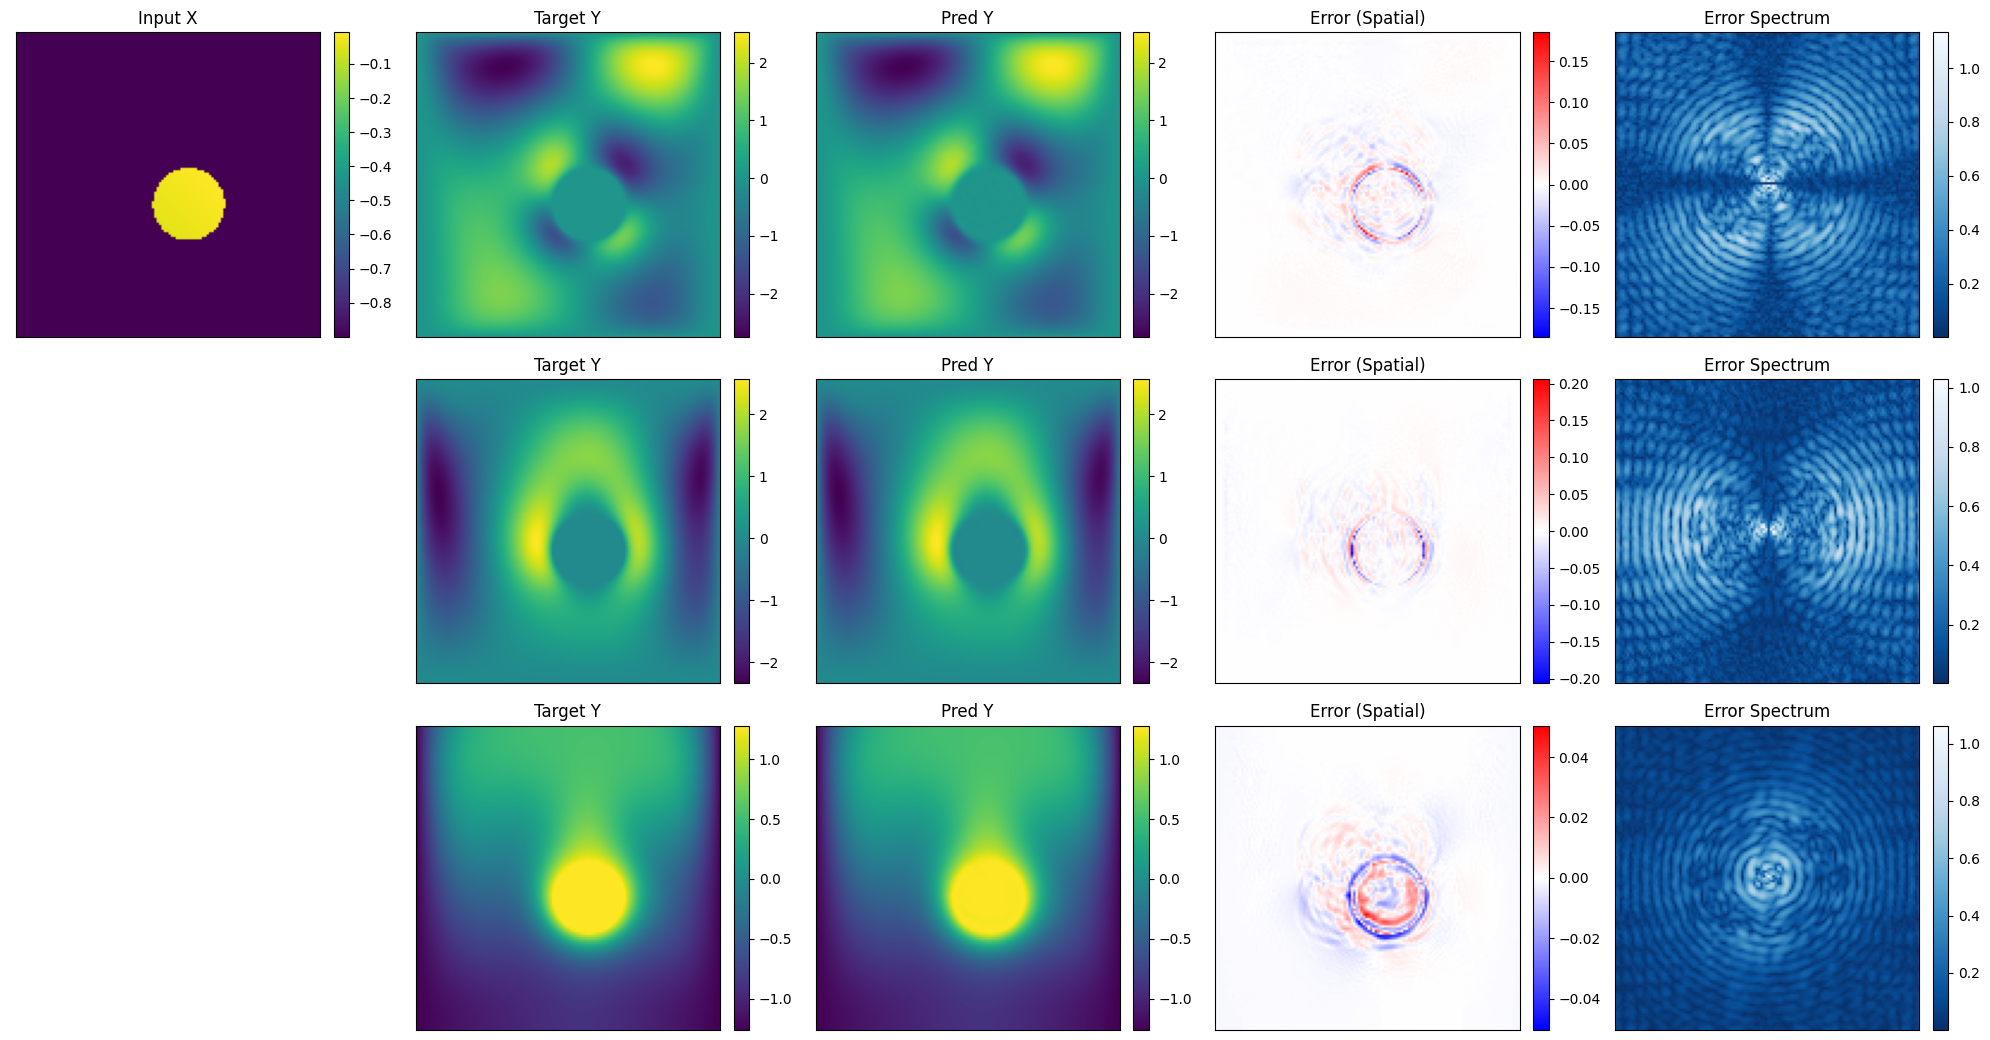

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

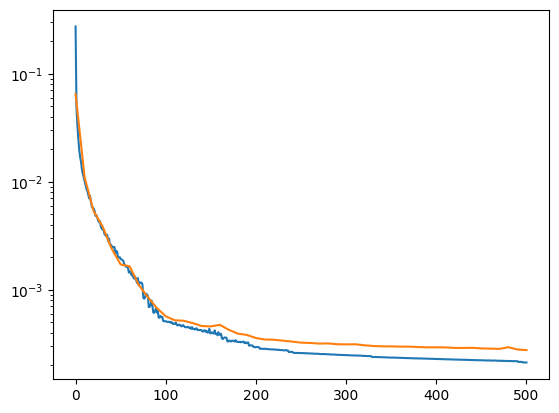

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## TE_Heat

In [ ]:
from utils import MPData
data_name = 'TE_heat'
model_name= 'MPodONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import MPodONet
from neuralop.utils import count_model_params
p = 2048
model = MPodONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 12,001,472 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 12,001,472


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.11/0.13 | loss: 1.45e+00 | test: 1.38e+00 | norm: 0.09


epoch:10 | time: 3.09/0.13 | loss: 7.35e-01 | test: 6.83e-01 | norm: 0.30


epoch:20 | time: 3.12/0.13 | loss: 2.73e-01 | test: 2.55e-01 | norm: 0.22


epoch:30 | time: 3.08/0.13 | loss: 1.45e-01 | test: 1.34e-01 | norm: 0.16


epoch:40 | time: 3.08/0.13 | loss: 1.01e-01 | test: 9.09e-02 | norm: 0.14


...

epoch:470 | time: 3.12/0.13 | loss: 9.08e-04 | test: 8.49e-04 | norm: 0.00


epoch:480 | time: 3.12/0.13 | loss: 8.88e-04 | test: 8.22e-04 | norm: 0.00


epoch:490 | time: 3.09/0.13 | loss: 8.77e-04 | test: 8.14e-04 | norm: 0.00


epoch:499 | time: 3.12/0.13 | loss: 8.55e-04 | test: 7.99e-04 | norm: 0.00


Finish epoch:499 | train loss: 8.5478e-04 | test loss: 7.9888e-04
total train time : 1553.117
Channel Loss: var0: 3.5982e-04 var1: 3.6148e-04 var2: 7.7579e-05 



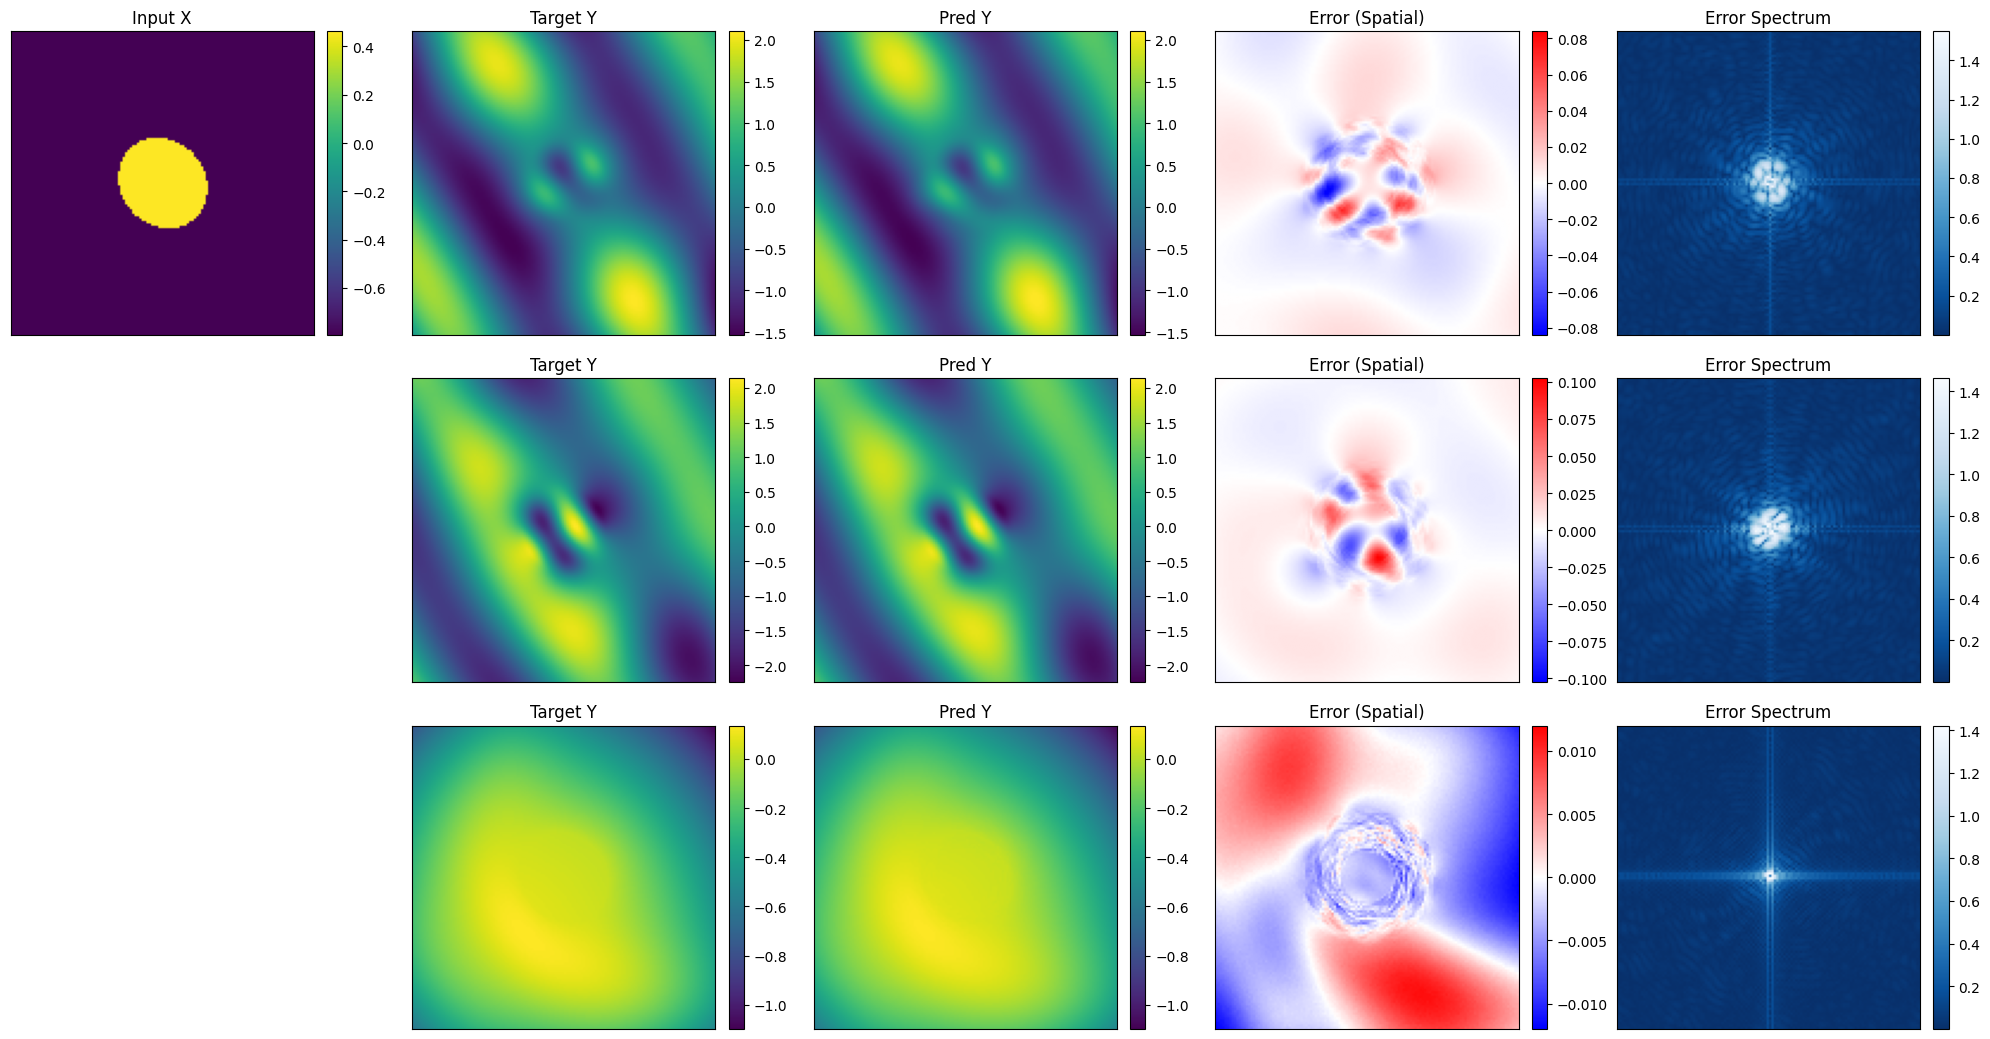

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

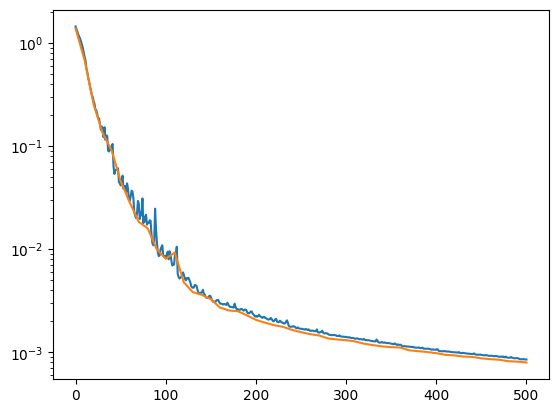

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## E_flow

In [ ]:
from utils import MPData
data_name = 'E_flow'
model_name= 'MPodONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import MPodONet
from neuralop.utils import count_model_params
p = 512
model = MPodONet(p=p).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 10,427,072 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 10,427,072


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.30/0.13 | loss: 9.31e-01 | test: 4.50e-01 | norm: 0.64


epoch:10 | time: 3.34/0.13 | loss: 1.91e-01 | test: 1.96e-01 | norm: 1.16


epoch:20 | time: 3.33/0.13 | loss: 1.48e-01 | test: 1.43e-01 | norm: 0.86


epoch:30 | time: 3.34/0.13 | loss: 1.20e-01 | test: 1.19e-01 | norm: 0.49


epoch:40 | time: 3.29/0.13 | loss: 1.02e-01 | test: 9.88e-02 | norm: 0.36


...

epoch:470 | time: 3.33/0.13 | loss: 5.52e-02 | test: 5.50e-02 | norm: 0.01


epoch:480 | time: 3.29/0.13 | loss: 5.52e-02 | test: 5.49e-02 | norm: 0.00


epoch:490 | time: 3.33/0.13 | loss: 5.51e-02 | test: 5.49e-02 | norm: 0.00


epoch:499 | time: 3.34/0.13 | loss: 5.51e-02 | test: 5.49e-02 | norm: 0.00


Finish epoch:499 | train loss: 5.5072e-02 | test loss: 5.4869e-02
total train time : 1659.848
Channel Loss: var0: 3.6486e-04 var1: 2.4148e-02 var2: 3.0357e-02 



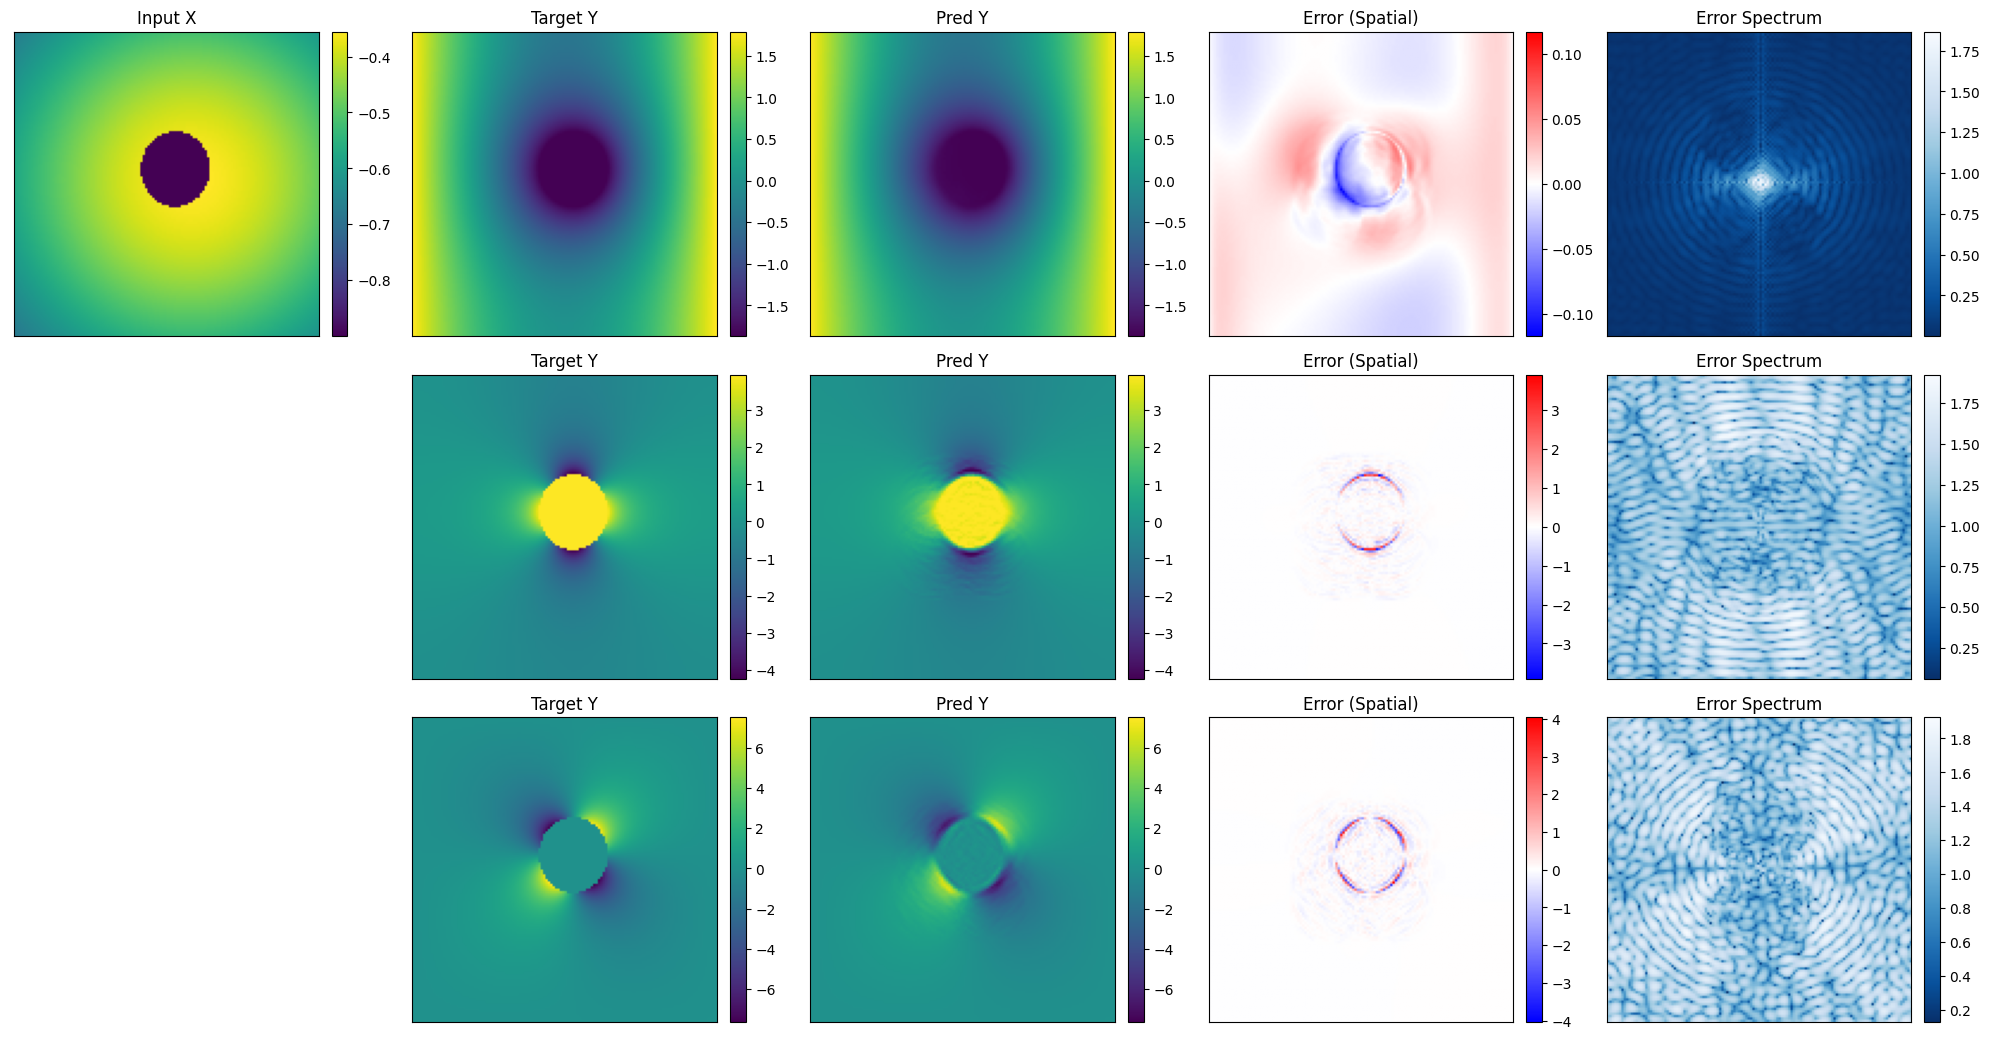

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=3)

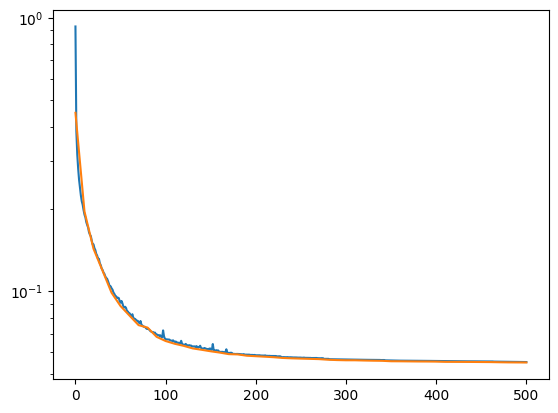

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')

## MHD

In [ ]:
from utils import MPData
data_name = 'MHD'
model_name= 'MPodONet'
mpdata = MPData(
    "/home/user/Data/Multiphysics_Bench/merge_data",
    data_name, 
    dry_run=False,
)
train_loader, test_loader = mpdata.loader()

In [ ]:
from models.MFPCA import MPodONet
from neuralop.utils import count_model_params
p = 512
model = MPodONet(p=p, out_channels=5).to(device)
n_params = count_model_params(model)
print(f"\nOur model has {n_params:,} parameters.")

model.pca_fit(mpdata.train_data['y'], device=device)


Our model has 10,427,072 parameters.


In [ ]:
learner = Learner(model, device=device, 
                  model_name=f'{data_name}/{model_name}_p{p}', epochs=epochs)
learner.model_summarize()
# learner.load(f'logs/{data_name}/{model_name}_p{p}')

total number of parameters: 10,427,072


In [ ]:
checkpoint = learner.train(
    train_loader, test_loader,epochs=epochs,
    print_every=print_every, save=save, save_every=save)

print(f"total train time : {sum(checkpoint['train_time']):.3f}")
chan_loss = learner.eval_channel()

epoch:0 | time: 3.99/0.17 | loss: 6.27e-01 | test: 6.81e-02 | norm: 0.19


epoch:10 | time: 3.91/0.16 | loss: 2.14e-02 | test: 3.09e-02 | norm: 0.05


epoch:20 | time: 3.93/0.16 | loss: 1.99e-02 | test: 2.79e-02 | norm: 0.03


epoch:30 | time: 3.94/0.17 | loss: 1.91e-02 | test: 2.70e-02 | norm: 0.02


epoch:40 | time: 3.95/0.16 | loss: 1.86e-02 | test: 2.66e-02 | norm: 0.02


...

epoch:470 | time: 3.98/0.16 | loss: 1.76e-02 | test: 2.57e-02 | norm: 0.01


epoch:480 | time: 3.98/0.16 | loss: 1.76e-02 | test: 2.57e-02 | norm: 0.01


epoch:490 | time: 3.98/0.16 | loss: 1.76e-02 | test: 2.57e-02 | norm: 0.01


epoch:499 | time: 3.98/0.17 | loss: 1.76e-02 | test: 2.57e-02 | norm: 0.01


Finish epoch:499 | train loss: 1.7643e-02 | test loss: 2.5652e-02
total train time : 1969.197
Channel Loss: var0: 2.6705e-04 var1: 1.9432e-04 var2: 2.5119e-02 var3: 1.6071e-05 var4: 5.5116e-05 



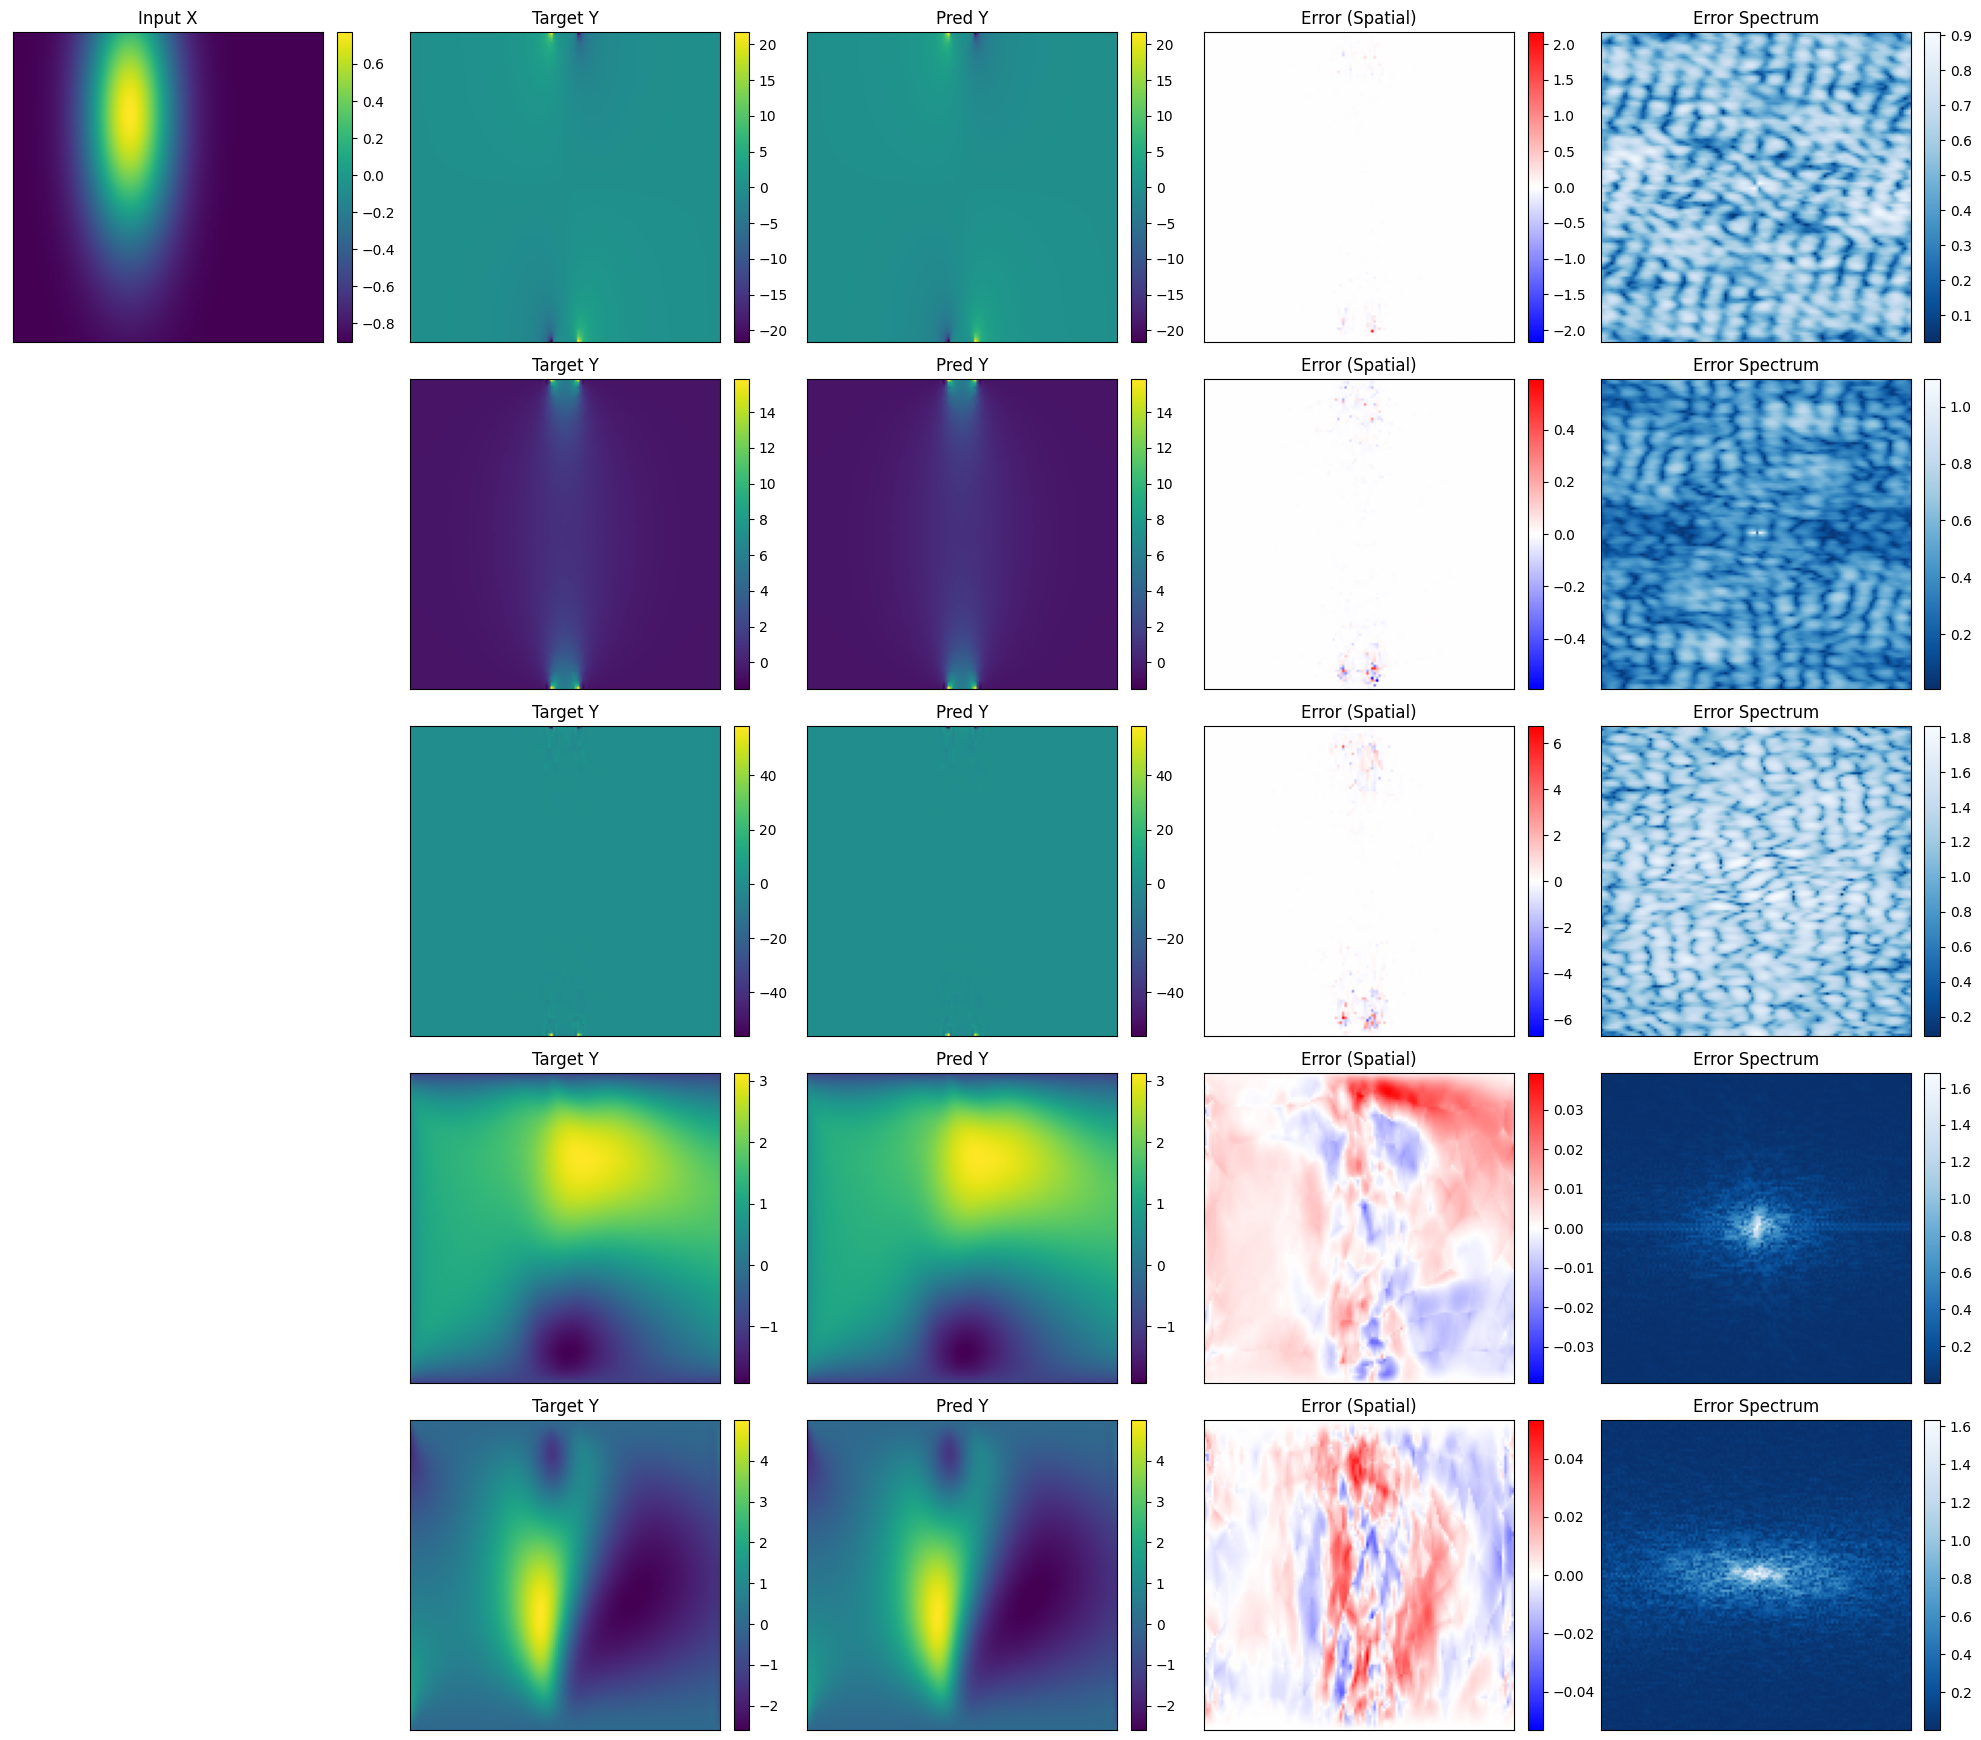

In [ ]:
from utils import plot_data
plot_data(test_loader, datatype='kh', pred_model=model,device=device, idx = 0, channel_x=1, channel_y=5)

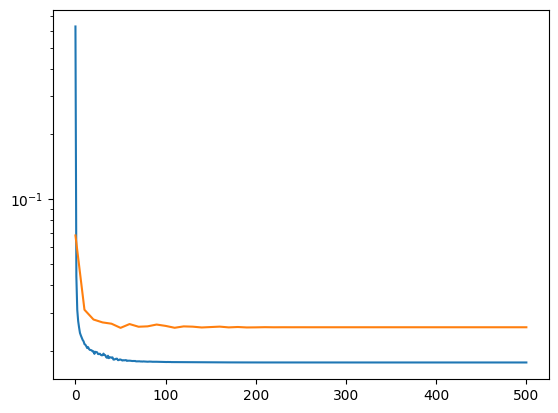

In [ ]:
import matplotlib.pyplot as plt
plt.plot(torch.linspace(0, len(checkpoint['train_loss']),len(checkpoint['train_loss'])), checkpoint['train_loss'])
plt.plot(torch.linspace(0, len(checkpoint['train_loss']), len(checkpoint['test_loss'])), checkpoint['test_loss'])
plt.yscale('log')